In [5]:
!nvidia-smi

Wed Dec 10 13:08:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.9 MB/s eta 0:00:00


In [7]:
import torch
from ultralytics import YOLO
import pandas as pd
import os
import time

In [8]:
model = YOLO('yolo12l.pt')

In [9]:
# --- CONFIGURATION ---
# Set device to GPU if available, otherwise CPU
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = 'yolo12l.pt' # Ensure this file is in your directory

In [10]:
# List of image files corresponding to the four lanes
LANE_IMAGES = ['North.png', 'South.png', 'East.png', 'West.png']

In [11]:
# --- Your Custom Algorithm Parameters ---
# Defined Alpha Coefficients (Weights)
ALPHA = {
    'bike': 0.5,
    'car': 1.0,
    'heavy': 2.5,  # Bus/Truck
    'emergency': 100.0
}

# Total theoretical maximum capacity for normalization
C_MAX = 500.0

# Signal Constraints (in seconds)
T_MAX_LIMIT = 90
T_MIN_LIMIT = 15

In [12]:
# --- CRUCIAL: Adjust Class Mapping ---
# Map the model's output class ID (e.g., 0) to your algorithm's vehicle type (e.g., 'car')
# You MUST verify these IDs for your specific yolov12l.pt model!
CLASS_MAP = {
    2: 'car',
    3: 'bike',
    5: 'heavy',
    7: 'heavy',
}

print(f"Configuration Complete. Running on {DEVICE}.")

Configuration Complete. Running on cuda:0.


In [13]:
# --- Step 1: Model Loading ---
try:
    print(f"Loading model {MODEL_PATH}...")
    # Load model and move it to the configured device (GPU/CPU)
    model = YOLO(MODEL_PATH).to(DEVICE)
    print("Model loaded successfully.")

except FileNotFoundError:
    print(f"ERROR: Model file not found at {MODEL_PATH}. Check directory and path.")
    # Stop execution if the model cannot be found
    raise

Loading model yolo12l.pt...
Model loaded successfully.


In [14]:
# --- Step 2: Detection Function ---
def count_vehicles(image_path, model, class_map):
    """Runs inference on an image and returns a dictionary of vehicle counts."""

    # Run inference with confidence threshold set to 50%
    results = model(image_path, stream=False, conf=0.5, iou=0.7, verbose=False)

    counts = {'bike': 0, 'car': 0, 'heavy': 0, 'emergency': 0}

    for result in results:
        # Get the predicted class IDs
        class_ids = result.boxes.cls.tolist()

        for class_id in class_ids:
            class_id = int(class_id)
            if class_id in class_map:
                vehicle_type = class_map[class_id]
                counts[vehicle_type] += 1

    return counts

print("Detection function defined.")

Detection function defined.


In [15]:
# --- Step 3: Execute Detection and Store Counts ---
all_counts = {}
for lane_img in LANE_IMAGES:
    lane_name = os.path.splitext(lane_img)[0]
    if os.path.exists(lane_img):
        all_counts[lane_name] = count_vehicles(lane_img, model, CLASS_MAP)
        print(f"Counted vehicles in {lane_name}: {all_counts[lane_name]}")
    else:
        print(f"WARNING: Image file not found for {lane_img}. Setting counts to zero.")
        all_counts[lane_name] = {'bike': 0, 'car': 0, 'heavy': 0, 'emergency': 0}

df_counts = pd.DataFrame.from_dict(all_counts, orient='index')

Counted vehicles in North: {'bike': 0, 'car': 6, 'heavy': 0, 'emergency': 0}
Counted vehicles in South: {'bike': 0, 'car': 7, 'heavy': 0, 'emergency': 0}
Counted vehicles in East: {'bike': 0, 'car': 6, 'heavy': 2, 'emergency': 0}
Counted vehicles in West: {'bike': 0, 'car': 5, 'heavy': 1, 'emergency': 0}


In [16]:
# --- Step 4: Adaptive Signal Priority Factor Algorithm ---

# 4.1 Congestion Score Calculation (S_total)
df_counts['S_total'] = (
    df_counts['bike'] * ALPHA['bike'] +
    df_counts['car'] * ALPHA['car'] +
    df_counts['heavy'] * ALPHA['heavy'] +
    df_counts['emergency'] * ALPHA['emergency']
)

In [17]:
# 4.2 Pairwise Density Aggregation (Phi)
phi_NS = df_counts.loc['North', 'S_total'] + df_counts.loc['South', 'S_total']
phi_EW = df_counts.loc['East', 'S_total'] + df_counts.loc['West', 'S_total']

print("\n--- Algorithm Decision ---")
print(f"Density NS ($\Phi_{{NS}}$): {phi_NS:.2f} | Density EW ($\Phi_{{EW}}$): {phi_EW:.2f}")


--- Algorithm Decision ---
Density NS ($\Phi_{NS}$): 13.00 | Density EW ($\Phi_{EW}$): 18.50


<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipython-input-76040286.py:6: SyntaxWarning: invalid escape sequence '\P'
  print(f"Density NS ($\Phi_{{NS}}$): {phi_NS:.2f} | Density EW ($\Phi_{{EW}}$): {phi_EW:.2f}")
/tmp/ipython-input-76040286.py:6: SyntaxWarning: invalid escape sequence '\P'
  print(f"Density NS ($\Phi_{{NS}}$): {phi_NS:.2f} | Density EW ($\Phi_{{EW}}$): {phi_EW:.2f}")


In [18]:
# 4.3 Priority Determination
if phi_NS >= phi_EW:
    priority_pair = 'North-South'
    max_density = phi_NS
else:
    priority_pair = 'East-West'
    max_density = phi_EW

In [19]:
# 4.4 Green Time Calculation and Clamping
T_calc = (max_density / C_MAX) * T_MAX_LIMIT

# Check for Emergency Override
if df_counts['emergency'].sum() > 0:
    T_green_final = T_MAX_LIMIT
    print("STATUS: Emergency Override! Max time set.")
else:
    # Apply safety constraints (T_min and T_max)
    T_green_final = max(T_MIN_LIMIT, min(T_calc, T_MAX_LIMIT))

In [20]:
# 4.5 Output Final Signal Time
non_priority_pair = 'East-West' if priority_pair == 'North-South' else 'North-South'
red_time = T_green_final + 3 # Add 3 seconds for Yellow clearance

print(f"\nPRIORITY: {priority_pair}")
print(f"Green Signal Time: {T_green_final:.2f} seconds")
print(f"Red Signal Time for {non_priority_pair}: {red_time:.2f} seconds")

print("\n--- Full Density Data ---")
print(df_counts[['S_total']].sort_values(by='S_total', ascending=False))


PRIORITY: East-West
Green Signal Time: 15.00 seconds
Red Signal Time for North-South: 18.00 seconds

--- Full Density Data ---
       S_total
East      11.0
West       7.5
South      7.0
North      6.0


In [22]:
import matplotlib.pyplot as plt
import cv2 # Used by YOLO for plotting

Processing: North.png
Processing: South.png
Processing: East.png
Processing: West.png


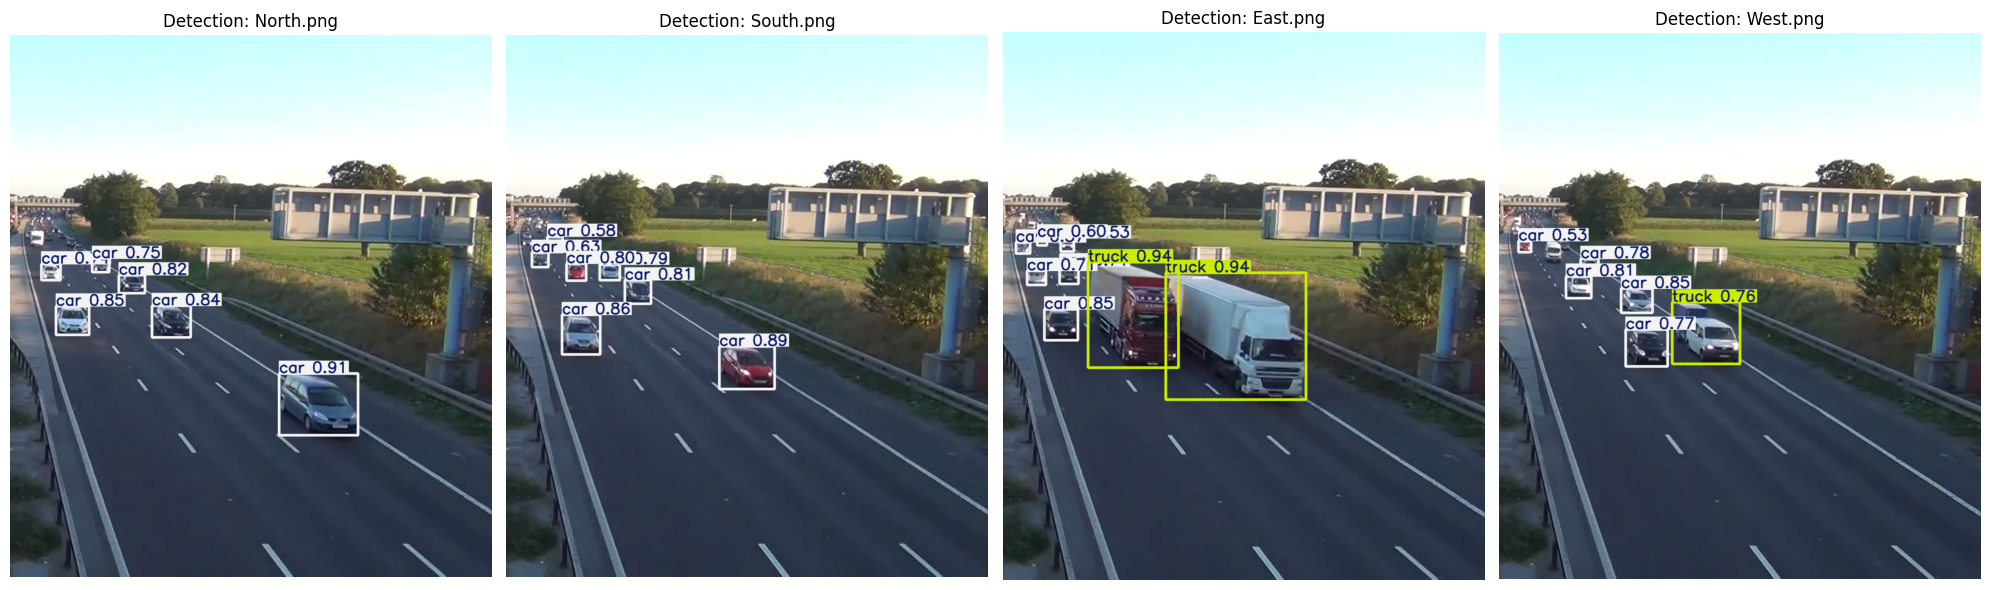

In [23]:
# Create a figure to display all images
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.flatten()

# Ensure images exist
images_to_process = [img for img in LANE_IMAGES if os.path.exists(img)]

if not images_to_process:
    print("No image files found in the current directory.")
else:
    for i, image_path in enumerate(images_to_process):
        print(f"Processing: {image_path}")

        # 1. Run Detection
        # conf=0.5: Only show detections with confidence > 50%
        # iou=0.7: Filter out highly overlapping boxes
        results = model(image_path, conf=0.5, iou=0.7, verbose=False)

        # 2. Get the image with bounding boxes drawn (plotted results)
        # Ultralytics results objects contain a plotted tensor/array
        plotted_image = results[0].plot()

        # 3. Convert from BGR (OpenCV default) to RGB (Matplotlib default)
        # The plotted image is typically a numpy array in BGR format
        plotted_image_rgb = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)

        # 4. Display the image in the subplot
        axes[i].imshow(plotted_image_rgb)
        axes[i].set_title(f"Detection: {os.path.basename(image_path)}")
        axes[i].axis('off')

    # Hide any unused subplots if fewer than 4 images were found
    for j in range(len(images_to_process), 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()